# Wan 2.2 T2V-A14B Video Generation on AWS Trainium2

End-to-end text-to-video generation with **Wan 2.2 T2V-A14B** (27B MoE, 14B active per step) on a single `trn2.48xlarge` instance.

## Architecture

- **Model**: Wan 2.2 T2V-A14B — Mixture of Experts (MoE) with 2 transformer experts (14.29B params each, zero weight sharing)
- **Resolution**: 768×1280, 81 frames, 50 denoising steps
- **Parallelism**: TP=4, CP=4 (16 NeuronCores per expert)
- **Key optimizations**:
  - Subprocess isolation for clean HBM lifecycle (99.8% HBM utilization)
  - Expert 2 preloading overlapped with Expert 1 denoising (saves ~205s)
  - Neuron tiled VAE decode (8 parallel tiles, 18× faster than CPU)

## Pipeline Flow

```
1. Load pipeline on CPU, encode text with UMT5-XXL
2. Start Expert 2 preload on cores 32-47 (background)
3. Expert 1 denoising on cores 48-63 (16 high-noise steps)
4. Expert 2 denoising on cores 32-47 (34 low-noise steps, zero-wait)
5. Neuron tiled VAE decode (8 tiles on cores 0-7)
6. Export video
```

## Prerequisites

- `trn2.48xlarge` instance with Deep Learning AMI Neuron (Ubuntu 24.04)
- Pre-installed venv: `/opt/aws_neuronx_venv_pytorch_2_9_nxd_inference/`
- NVMe storage mounted (1.7 TB)

**Expected total time**: ~30 min setup/compile + ~21 min inference = ~51 min

## Step 1: Environment Setup

In [1]:
import os
import subprocess
import sys

# Configuration
NVME_MOUNT = "/opt/dlami/nvme"
MODELS_DIR = f"{NVME_MOUNT}/models"
MODEL_NAME = "Wan2.2-T2V-A14B-Diffusers"
MODEL_DIR = f"{MODELS_DIR}/{MODEL_NAME}"
COMPILED_DIR = f"{NVME_MOUNT}/compiled_a14b_tp4"
COMPILER_WORKDIR = f"{NVME_MOUNT}/compiler_workdir"
CACHE_DIR = f"{NVME_MOUNT}/wan2.2_t2v_a14b_hf_cache_dir"
HENAN_DIR = f"{NVME_MOUNT}/aws-neuron-samples/torch-neuronx/inference/hf_pretrained_wan2.2_t2v_a14b"
VENV = "/opt/aws_neuronx_venv_pytorch_2_9_nxd_inference"

# Parallelism
TP_DEGREE = 4
CP_DEGREE = 4
WORLD_SIZE = TP_DEGREE * CP_DEGREE  # 16

# Video generation
HEIGHT = 768
WIDTH = 1280
NUM_FRAMES = 81
NUM_STEPS = 50

print(f"TP={TP_DEGREE}, CP={CP_DEGREE}, World Size={WORLD_SIZE}")
print(f"Resolution: {HEIGHT}x{WIDTH}, {NUM_FRAMES} frames, {NUM_STEPS} steps")

TP=4, CP=4, World Size=16
Resolution: 768x1280, 81 frames, 50 steps


In [2]:
# Verify Neuron devices
!neuron-ls

instance-type: trn2.48xlarge
instance-id: i-026b9e20d51b91456
logical-neuroncore-config: 2
+--------+--------+----------+--------+---------------+--------------+---------------+------+
| NEURON | NEURON |  NEURON  | NEURON |   CONNECTED   |     PCI      |      CPU      | NUMA |
| DEVICE | CORES  | CORE IDS | MEMORY |    DEVICES    |     BDF      |   AFFINITY    | NODE |
+--------+--------+----------+--------+---------------+--------------+---------------+------+
| 0      | 4      | 0-3      | 96 GB  | 12, 3, 4, 1   | 0000:cc:00.0 | 48-95,144-191 | 1    |
| 1      | 4      | 4-7      | 96 GB  | 13, 0, 5, 2   | 0000:b5:00.0 | 48-95,144-191 | 1    |
| 2      | 4      | 8-11     | 96 GB  | 14, 1, 6, 3   | 0000:b6:00.0 | 48-95,144-191 | 1    |
| 3      | 4      | 12-15    | 96 GB  | 15, 2, 7, 0   | 0000:cb:00.0 | 48-95,144-191 | 1    |
| 4      | 4      | 16-19    | 96 GB  | 0, 7, 8, 5    | 0000:6f:00.0 | 0-47,96-143   | 0    |
| 5      | 4      | 20-23    | 96 GB  | 1, 4, 9, 6    | 0000:58

In [3]:
# Verify SDK versions
!pip show neuronx-cc torch-neuronx neuronx-distributed 2>/dev/null | grep -E 'Name:|Version:'

Name: neuronx-cc
Version: 2.23.6484.0+3b612583


Name: torch-neuronx
Version: 2.9.0.2.12.22436+0f1dac25


Name: neuronx-distributed
Version: 0.17.26814+4b18de63


## Step 2: Mount NVMe Storage

In [4]:
%%bash -e
NVME_MOUNT="/opt/dlami/nvme"

if mountpoint -q "${NVME_MOUNT}" 2>/dev/null; then
    echo "NVMe already mounted at ${NVME_MOUNT}"
else
    # Find NVMe devices (exclude root EBS)
    NVME_DEVICES=$(lsblk -d -n -o NAME,TYPE | grep disk | grep nvme | awk '{print "/dev/"$1}' | sort)
    ROOT_DEV=$(findmnt -n -o SOURCE / | sed 's/p[0-9]*$//' | sed 's/[0-9]*$//')

    NVME_TO_MOUNT=""
    for dev in $NVME_DEVICES; do
        if [[ "$dev" != "$ROOT_DEV"* ]] && ! lsblk -n -o MOUNTPOINT "$dev" | grep -q '/'; then
            NVME_TO_MOUNT="$dev"
            break
        fi
    done

    if [ -z "$NVME_TO_MOUNT" ]; then
        echo "No unmounted NVMe found, using EBS storage"
        sudo mkdir -p "${NVME_MOUNT}"
        sudo chown ubuntu:ubuntu "${NVME_MOUNT}"
    else
        echo "Formatting and mounting ${NVME_TO_MOUNT}..."
        sudo mkfs.ext4 -F "$NVME_TO_MOUNT"
        sudo mkdir -p "${NVME_MOUNT}"
        sudo mount "$NVME_TO_MOUNT" "${NVME_MOUNT}"
        sudo chown ubuntu:ubuntu "${NVME_MOUNT}"
        echo "Mounted at ${NVME_MOUNT}"
    fi
fi

df -h ${NVME_MOUNT}

NVMe already mounted at /opt/dlami/nvme


Filesystem      Size  Used Avail Use% Mounted on
/dev/nvme0n1    1.7T   44K  1.7T   1% /opt/dlami/nv

me


In [5]:
# Create directories
for d in [MODELS_DIR, COMPILED_DIR, COMPILER_WORKDIR, CACHE_DIR]:
    os.makedirs(d, exist_ok=True)
print("Directories created.")

Directories created.


## Step 3: Install Dependencies

In [6]:
# Install required packages
!pip install -q diffusers accelerate imageio-ffmpeg

In [7]:
# Patch diffusers: nearest-exact -> nearest (required for Trainium2 VAE)
import diffusers

vae_path = os.path.join(
    os.path.dirname(diffusers.__file__),
    "models", "autoencoders", "autoencoder_kl_wan.py"
)
with open(vae_path) as f:
    content = f.read()
if "nearest-exact" in content:
    content = content.replace("nearest-exact", "nearest")
    with open(vae_path, "w") as f:
        f.write(content)
    print("Patched diffusers: nearest-exact -> nearest")
else:
    print("Diffusers already patched")

Diffusers already patched


## Step 4: Clone Neuron Samples (Compilation Code)

In [8]:
%%bash
NVME_MOUNT="/opt/dlami/nvme"
SAMPLES_DIR="${NVME_MOUNT}/aws-neuron-samples"
HENAN_DIR="${SAMPLES_DIR}/torch-neuronx/inference/hf_pretrained_wan2.2_t2v_a14b"

if [ -d "${HENAN_DIR}" ]; then
    echo "aws-neuron-samples already exists"
else
    echo "Cloning aws-neuron-samples..."
    git clone --depth 1 https://github.com/whn09/aws-neuron-samples.git "${SAMPLES_DIR}"
fi

echo "Compilation code directory:"
ls ${HENAN_DIR}/neuron_wan2_2_t2v_a14b/ || echo 'ERROR: Directory not found'

Cloning aws-neuron-samples...


Cloning into '/opt/dlami/nvme/aws-neuron-samples'...


Compilation code directory:


__init__.py
cache_hf_model.py
compile_decoder_nocache.py
compile_decoder_rolling.py
compile_text_enc

oder.py
compile_transformer.py
decoder_worker.py
denoise_worker.py
distributed_rmsnorm.py
neuron_com

mons.py
neuron_parallel_utils.py
persistent_decoder_worker.py
persistent_denoise_worker.py
persisten

t_text_encoder_worker.py
persistent_tile_decoder_worker.py
text_encoder_worker.py
tiled_decoder_work

er.py


## Step 5: Download Model (118 GB)

This downloads the full Wan 2.2 T2V-A14B model from HuggingFace (~10-15 minutes).

In [9]:
if os.path.exists(os.path.join(MODEL_DIR, "model_index.json")):
    print(f"Model already downloaded at {MODEL_DIR}")
else:
    print(f"Downloading Wan-AI/Wan2.2-T2V-A14B-Diffusers (118 GB)...")
    from huggingface_hub import snapshot_download
    snapshot_download(
        "Wan-AI/Wan2.2-T2V-A14B-Diffusers",
        local_dir=MODEL_DIR,
        local_dir_use_symlinks=False,
    )
    print("Download complete.")

!du -sh {MODEL_DIR}

Fetching 49 files:   0%|          | 0/49 [00:00<?, ?it/s]

/opt/aws_neuronx_venv_pytorch_2_9_nxd_inference/lib/python3.12/site-packages/huggingface_hub/file_download.py:986: UserWarning: `local_dir_use_symlinks` parameter is deprecated and will be ignored. The process to download files to a local folder has been updated and do not rely on symlinks anymore. You only need to pass a destination folder as`local_dir`.
For more details, check out https://huggingface.co/docs/huggingface_hub/main/en/guides/download#download-files-to-local-folder.
  warnings.warn(


moe_arch.png:   0%|          | 0.00/74.9k [00:00<?, ?B/s]

logo.png:   0%|          | 0.00/56.3k [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

transformer_2/diffusion_pytorch_model-00(…):   0%|          | 0.00/3.10G [00:00<?, ?B/s]

(…)ion_pytorch_model.safetensors.index.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/724 [00:00<?, ?B/s]

vae/diffusion_pytorch_model.safetensors:   0%|          | 0.00/508M [00:00<?, ?B/s]

Download complete.
118G	/opt/dlami/nvme/models/Wan2.2-T2V-A14B-Diffusers


## Step 6: Compile Models

Compilation of all 4 artifacts:
1. **Text encoder** (UMT5-XXL) — ~2 min
2. **Transformer Expert 1** (high-noise) — ~12 min
3. **Transformer Expert 2** (low-noise) — ~12 min
4. **Tiled VAE decoder** (416×416 tiles) — ~3 min

Total compilation: ~30 minutes.

In [10]:
# Set up environment for compilation
os.environ["NEURON_RT_VIRTUAL_CORE_SIZE"] = "2"
os.environ["PYTHONPATH"] = HENAN_DIR + ":" + os.environ.get("PYTHONPATH", "")
print(f"PYTHONPATH includes: {HENAN_DIR}")

PYTHONPATH includes: /opt/dlami/nvme/aws-neuron-samples/torch-neuronx/inference/hf_pretrained_wan2.2_t2v_a14b


In [11]:
%%bash -e
# Cache HuggingFace model
NVME_MOUNT="/opt/dlami/nvme"
HENAN_DIR="${NVME_MOUNT}/aws-neuron-samples/torch-neuronx/inference/hf_pretrained_wan2.2_t2v_a14b"
CACHE_DIR="${NVME_MOUNT}/wan2.2_t2v_a14b_hf_cache_dir"

export PYTHONPATH="${HENAN_DIR}:${PYTHONPATH:-}"
python ${HENAN_DIR}/neuron_wan2_2_t2v_a14b/cache_hf_model.py --cache_dir ${CACHE_DIR} 2>&1 | tail -5

Loading pip

Loading pipeline co

Loading pipeline compon

ents...: 100%|██████████| 6/6 [00:34<00:00,  5.77s/it]


Download complete!

### 6a: Compile Text Encoder

In [12]:
%%bash -e
NVME_MOUNT="/opt/dlami/nvme"
HENAN_DIR="${NVME_MOUNT}/aws-neuron-samples/torch-neuronx/inference/hf_pretrained_wan2.2_t2v_a14b"
COMPILED_DIR="${NVME_MOUNT}/compiled_a14b_tp4"
CACHE_DIR="${NVME_MOUNT}/wan2.2_t2v_a14b_hf_cache_dir"
export PYTHONPATH="${HENAN_DIR}:${PYTHONPATH:-}"
export NEURON_RT_VIRTUAL_CORE_SIZE=2

if [ -f "${COMPILED_DIR}/text_encoder/nxd_model.pt" ]; then
    echo "Text encoder already compiled"
else
    echo "Compiling text encoder (TP=4)..."
    WORLD_SIZE=8 neuron_parallel_compile python \
        ${HENAN_DIR}/neuron_wan2_2_t2v_a14b/compile_text_encoder.py \
        --max_sequence_length 512 \
        --tp_degree 4 --world_size 8 \
        --compiled_models_dir ${COMPILED_DIR} \
        --cache_dir ${CACHE_DIR} \
        2>&1 | tail -10
    echo "Text encoder compiled."
fi

ls -lh ${COMPILED_DIR}/text_encoder/nxd_model.pt

Compiling text encoder (TP=4)...


  warnings.warn(f"Removing redundant keys from checkpoint: {keys_to_delete}")
Sharding text encoder 

blocks...
Initializing ModelBuilder...
Tracing model...
Compiling model...
Saving compiled model to 

/opt/dlami/nvme/compiled_a14b_tp4/text_encoder...
Saving sharded weights...
Done! Text encoder saved

 to /opt/dlami/nvme/compiled_a14b_tp4/text_encoder
2026-04-07 04:07:29.000471:  24819  [INFO]: Found

 0 graphs from trial run log: []
2026-04-07 04:07:29.000472:  24819  [INFO]: parallel_compile: No HL

Os to compile (cache_url=<libneuronxla.neuron_cc_cache.CacheUrl object at 0x7a1208f15160>, tasklist_

len=0), skipping worker spawn


Text encoder compiled.
-rw-rw-r-- 1 ubuntu ubuntu 199M Apr  7 04:06 /opt/dlami/nvme/compiled_a14b_tp

4/text_encoder/nxd_model.pt


### 6b: Compile Transformer Expert 1 (High Noise)

This is the larger compilation step (~12 minutes). The transformer has 40 layers with NKI flash attention.

In [13]:
%%bash -e
NVME_MOUNT="/opt/dlami/nvme"
HENAN_DIR="${NVME_MOUNT}/aws-neuron-samples/torch-neuronx/inference/hf_pretrained_wan2.2_t2v_a14b"
COMPILED_DIR="${NVME_MOUNT}/compiled_a14b_tp4"
CACHE_DIR="${NVME_MOUNT}/wan2.2_t2v_a14b_hf_cache_dir"
COMPILER_WORKDIR="${NVME_MOUNT}/compiler_workdir"
export PYTHONPATH="${HENAN_DIR}:${PYTHONPATH:-}"
export NEURON_RT_VIRTUAL_CORE_SIZE=2

if [ -f "${COMPILED_DIR}/transformer/nxd_model.pt" ]; then
    echo "Expert 1 already compiled"
else
    echo "Compiling transformer Expert 1 (TP=4, CP=4)..."
    WORLD_SIZE=16 neuron_parallel_compile python \
        ${HENAN_DIR}/neuron_wan2_2_t2v_a14b/compile_transformer.py \
        --height 768 --width 1280 --num_frames 81 --max_sequence_length 512 \
        --tp_degree 4 --cp_degree 4 --batch_size 1 \
        --transformer_subfolder transformer \
        --compiled_models_dir ${COMPILED_DIR} \
        --compiler_workdir ${COMPILER_WORKDIR}/expert1 \
        --cache_dir ${CACHE_DIR} \
        2>&1 | tail -10
    echo "Expert 1 compiled."
fi

ls -lh ${COMPILED_DIR}/transformer/nxd_model.pt

Compiling transformer Expert 1 (TP=4, CP=4)...


Fixing norm weights for 4 ranks...
  Rank 0: Fixed 160 norm weights
  Rank 1: Fixed 160 norm weights


  Rank 2: Fixed 160 norm weights
  Rank 3: Fixed 160 norm weights

Compilation complete!
Model save

d to: /opt/dlami/nvme/compiled_a14b_tp4/transformer
2026-04-07 04:20:37.000774:  26285  [INFO]: Foun

d 0 graphs from trial run log: []
2026-04-07 04:20:37.000774:  26285  [INFO]: parallel_compile: No H

LOs to compile (cache_url=<libneuronxla.neuron_cc_cache.CacheUrl object at 0x78429c2923f0>, tasklist

_len=0), skipping worker spawn


Expert 1 compiled.
-rw-rw-r-- 1 ubuntu ubuntu 297M Apr  7 04:18 /opt/dlami/nvme/compiled_a14b_tp4/tr

ansformer/nxd_model.pt


### 6c: Compile Transformer Expert 2 (Low Noise)

In [14]:
%%bash -e
NVME_MOUNT="/opt/dlami/nvme"
HENAN_DIR="${NVME_MOUNT}/aws-neuron-samples/torch-neuronx/inference/hf_pretrained_wan2.2_t2v_a14b"
COMPILED_DIR="${NVME_MOUNT}/compiled_a14b_tp4"
CACHE_DIR="${NVME_MOUNT}/wan2.2_t2v_a14b_hf_cache_dir"
COMPILER_WORKDIR="${NVME_MOUNT}/compiler_workdir"
export PYTHONPATH="${HENAN_DIR}:${PYTHONPATH:-}"
export NEURON_RT_VIRTUAL_CORE_SIZE=2

if [ -f "${COMPILED_DIR}/transformer_2/nxd_model.pt" ]; then
    echo "Expert 2 already compiled"
else
    echo "Compiling transformer Expert 2 (TP=4, CP=4)..."
    WORLD_SIZE=16 neuron_parallel_compile python \
        ${HENAN_DIR}/neuron_wan2_2_t2v_a14b/compile_transformer.py \
        --height 768 --width 1280 --num_frames 81 --max_sequence_length 512 \
        --tp_degree 4 --cp_degree 4 --batch_size 1 \
        --transformer_subfolder transformer_2 \
        --compiled_models_dir ${COMPILED_DIR} \
        --compiler_workdir ${COMPILER_WORKDIR}/expert2 \
        --cache_dir ${CACHE_DIR} \
        2>&1 | tail -10
    echo "Expert 2 compiled."
fi

ls -lh ${COMPILED_DIR}/transformer_2/nxd_model.pt

Compiling transformer Expert 2 (TP=4, CP=4)...


Fixing norm weights for 4 ranks...
  Rank 0: Fixed 160 norm weights
  Rank 1: Fixed 160 norm weights


  Rank 2: Fixed 160 norm weights
  Rank 3: Fixed 160 norm weights

Compilation complete!
Model save

d to: /opt/dlami/nvme/compiled_a14b_tp4/transformer_2
2026-04-07 04:34:14.000047:  27867  [INFO]: Fo

und 0 graphs from trial run log: []
2026-04-07 04:34:14.000048:  27867  [INFO]: parallel_compile: No

 HLOs to compile (cache_url=<libneuronxla.neuron_cc_cache.CacheUrl object at 0x7e23f427f1d0>, taskli

st_len=0), skipping worker spawn


Expert 2 compiled.
-rw-rw-r-- 1 ubuntu ubuntu 297M Apr  7 04:32 /opt/dlami/nvme/compiled_a14b_tp4/tr

ansformer_2/nxd_model.pt


### 6d: Compile Tiled VAE Decoder

In [15]:
%%bash -e
NVME_MOUNT="/opt/dlami/nvme"
HENAN_DIR="${NVME_MOUNT}/aws-neuron-samples/torch-neuronx/inference/hf_pretrained_wan2.2_t2v_a14b"
COMPILED_DIR="${NVME_MOUNT}/compiled_a14b_tp4"
CACHE_DIR="${NVME_MOUNT}/wan2.2_t2v_a14b_hf_cache_dir"
COMPILER_WORKDIR="${NVME_MOUNT}/compiler_workdir"
export PYTHONPATH="${HENAN_DIR}:${PYTHONPATH:-}"
export NEURON_RT_VIRTUAL_CORE_SIZE=2

if [ -f "${COMPILED_DIR}/decoder_tile_ws1/nxd_model.pt" ]; then
    echo "Tiled VAE decoder already compiled"
else
    echo "Compiling tiled VAE decoder (416x416 tiles)..."
    NEURON_RT_NUM_CORES=2 python \
        ${HENAN_DIR}/neuron_wan2_2_t2v_a14b/compile_decoder_rolling.py \
        --height 416 --width 416 --num_frames 81 \
        --tp_degree 1 --world_size 1 \
        --output_subdir decoder_tile_ws1 \
        --compiled_models_dir ${COMPILED_DIR} \
        --compiler_workdir ${COMPILER_WORKDIR}/decoder \
        --cache_dir ${CACHE_DIR} \
        --skip_pqc \
        2>&1 | tail -10
    echo "Tiled VAE decoder compiled."
fi

ls -lh ${COMPILED_DIR}/decoder_tile_ws1/nxd_model.pt

Compiling tiled VAE decoder (416x416 tiles)...


Compiling...
Saving to /opt/dlami/nvme/compiled_a14b_tp4/decoder_tile_ws1...

Decoder (rolling, STAT

EFUL) saved to /opt/dlami/nvme/compiled_a14b_tp4/decoder_tile_ws1

Skipping post_quant_conv compilat

ion (--skip_pqc)

Compilation Complete!

Tiled VAE decoder compiled.


-rw-rw-r-- 1 ubuntu ubuntu 107M Apr  7 04:59 /opt/dlami/nvme/compiled_a14b_tp4/decoder_tile_ws1/nxd_

model.pt


### Verify All Compiled Artifacts

In [16]:
import json

artifacts = {
    "text_encoder": f"{COMPILED_DIR}/text_encoder/nxd_model.pt",
    "transformer (Expert 1)": f"{COMPILED_DIR}/transformer/nxd_model.pt",
    "transformer_2 (Expert 2)": f"{COMPILED_DIR}/transformer_2/nxd_model.pt",
    "decoder_tile_ws1 (VAE)": f"{COMPILED_DIR}/decoder_tile_ws1/nxd_model.pt",
}

all_ok = True
for name, path in artifacts.items():
    if os.path.exists(path):
        size_mb = os.path.getsize(path) / 1024 / 1024
        print(f"  OK: {name} ({size_mb:.0f} MB)")
    else:
        print(f"  MISSING: {name}")
        all_ok = False

# Show transformer config
config_path = f"{COMPILED_DIR}/transformer/config.json"
if os.path.exists(config_path):
    with open(config_path) as f:
        config = json.load(f)
    print(f"\nTransformer config: TP={config['tp_degree']}, CP={config['cp_degree']}, "
          f"world_size={config['world_size']}, seq_len={config['seq_len']}")

assert all_ok, "Some artifacts are missing. Check compilation logs above."

  OK: text_encoder (198 MB)
  OK: transformer (Expert 1) (297 MB)
  OK: transformer_2 (Expert 2) (297 MB)
  OK: decoder_tile_ws1 (VAE) (106 MB)

Transformer config: TP=4, CP=4, world_size=16, seq_len=80640


## Step 7: Run Inference

Now we run the full inference pipeline. This uses subprocess-based execution to manage HBM lifecycle:

- **Expert 1** runs on NeuronCores 48-63 (16 high-noise steps)
- **Expert 2** preloads on cores 32-47, then runs 34 low-noise steps
- **VAE decoder** runs on cores 0-7 (8 parallel tiles)

The worker scripts (`worker_denoise.py` and `worker_denoise_preload.py`) must be in the same directory as this notebook.

**Expected time**: ~21 minutes (model loading + 50 denoising steps + VAE decode)

In [17]:
# Verify worker scripts exist
notebook_dir = os.path.dirname(os.path.abspath("__file__"))

# When run via nbconvert, __file__ may not be set — use cwd
if not os.path.exists(os.path.join(notebook_dir, "worker_denoise.py")):
    notebook_dir = os.getcwd()

worker_script = os.path.join(notebook_dir, "worker_denoise.py")
preload_worker_script = os.path.join(notebook_dir, "worker_denoise_preload.py")

assert os.path.exists(worker_script), f"Missing: {worker_script}"
assert os.path.exists(preload_worker_script), f"Missing: {preload_worker_script}"
print(f"Worker scripts found in: {notebook_dir}")

Worker scripts found in: /home/ubuntu


In [18]:
import gc
import json
import math
import random
import shutil
import tempfile
import time

import numpy as np
import torch
import torch.nn.functional as F
from diffusers import AutoencoderKLWan, WanPipeline
from diffusers.utils import export_to_video

DTYPE = torch.bfloat16
SEED = 42
GUIDANCE_SCALE_HIGH = 4.0
GUIDANCE_SCALE_LOW = 3.0
BOUNDARY_RATIO = 0.875
MAX_SEQ_LEN = 512
TILED_DECODER_WORKER = "neuron_wan2_2_t2v_a14b.tiled_decoder_worker"

PROMPT = "A cat walks on the grass, realistic style, 4K quality"
NEGATIVE_PROMPT = (
    "Bright tones, overexposed, static, blurred details, subtitles, style, "
    "works, paintings, images, static, overall gray, worst quality, low quality, "
    "JPEG compression residue, ugly, incomplete, extra fingers, poorly drawn hands, "
    "poorly drawn faces, deformed, disfigured, misshapen limbs, fused fingers, "
    "still picture, messy background, three legs, many people in the background, "
    "walking backwards"
)

OUTPUT_PATH = "output_wan22_a14b.mp4"

print(f"Prompt: {PROMPT}")
print(f"Output: {OUTPUT_PATH}")

Prompt: A cat walks on the grass, realistic style, 4K quality
Output: output_wan22_a14b.mp4


In [19]:
# Helper functions

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


def get_neuron_env(world_size, core_start):
    """Build Neuron RT environment dict for a subprocess."""
    return {
        "NEURON_RT_NUM_CORES": str(world_size),
        "NEURON_RT_VIRTUAL_CORE_SIZE": "2",
        "NEURON_RT_VISIBLE_CORES": f"{core_start}-{core_start + world_size - 1}",
        "NEURON_RT_INSPECT_ENABLE": "0",
        "NEURON_RT_INSPECT_DEVICE_PROFILE": "0",
        "NEURON_RT_INSPECT_SYSTEM_PROFILE": "0",
        "NEURON_RT_PROFILING_MODE": "0",
    }


def make_clean_env():
    """Make a clean subprocess env (no inherited NEURON_RT_ vars)."""
    env = os.environ.copy()
    for k in list(env.keys()):
        if k.startswith("NEURON_RT_") or k == "NEURON_LOGICAL_NC_CONFIG":
            del env[k]
    env["PYTHONUNBUFFERED"] = "1"
    return env

In [20]:
# Expert subprocess functions

def run_expert_subprocess(
    compiled_path, pipe_transformer_state, latents,
    prompt_embeds, negative_prompt_embeds,
    step_start, step_end, guidance_scale, expand_timesteps, mask,
    scheduler_config, scheduler_state, num_inference_steps,
    world_size, core_start, label="expert",
):
    """Run denoising steps in a subprocess for clean HBM lifecycle."""
    tmpdir = tempfile.mkdtemp(prefix=f"denoise_{label}_")
    input_path = os.path.join(tmpdir, "input.pt")
    output_path = os.path.join(tmpdir, "output.pt")
    neuron_env = get_neuron_env(world_size, core_start)

    phase_data = {
        "compiled_path": compiled_path,
        "pipe_transformer_state": pipe_transformer_state,
        "latents": latents,
        "prompt_embeds": prompt_embeds,
        "negative_prompt_embeds": negative_prompt_embeds,
        "step_start": step_start, "step_end": step_end,
        "guidance_scale": guidance_scale,
        "expand_timesteps": expand_timesteps,
        "mask": mask,
        "scheduler_config": dict(scheduler_config),
        "scheduler_state": scheduler_state,
        "num_inference_steps": num_inference_steps,
        "neuron_env": neuron_env,
    }
    torch.save(phase_data, input_path)

    print(f"[Main] Launching {label} (steps {step_start}-{step_end-1}, "
          f"cores {core_start}-{core_start+world_size-1})...")
    t0 = time.time()
    env = make_clean_env()
    result = subprocess.run(
        [sys.executable, worker_script, input_path, output_path],
        env=env, timeout=3600,
    )
    if result.returncode != 0:
        raise RuntimeError(f"{label} failed with code {result.returncode}")

    output = torch.load(output_path, weights_only=False)
    elapsed = time.time() - t0
    print(f"[Main] {label} done in {elapsed:.1f}s "
          f"(load: {output['load_time']:.1f}s, denoise: {output['denoise_time']:.1f}s)")

    shutil.rmtree(tmpdir, ignore_errors=True)
    return output["latents"], output.get("scheduler_state"), output


def start_expert_preload(
    compiled_path, pipe_transformer_state,
    world_size, core_start, label="expert2",
):
    """Start preloading an expert model in a background subprocess."""
    workdir = tempfile.mkdtemp(prefix=f"preload_{label}_")
    preload_path = os.path.join(workdir, "preload.pt")
    neuron_env = get_neuron_env(world_size, core_start)

    preload_data = {
        "compiled_path": compiled_path,
        "pipe_transformer_state": pipe_transformer_state,
        "neuron_env": neuron_env,
    }
    torch.save(preload_data, preload_path)

    print(f"[Main] Starting preload for {label} on cores {core_start}-{core_start+world_size-1}...")
    env = make_clean_env()
    proc = subprocess.Popen(
        [sys.executable, preload_worker_script, workdir], env=env,
    )
    return workdir, proc


def finish_expert_denoise(
    workdir, proc, latents, prompt_embeds, negative_prompt_embeds,
    step_start, step_end, guidance_scale, expand_timesteps, mask,
    scheduler_config, scheduler_state, num_inference_steps,
    label="expert2",
):
    """Send input to a preloaded expert and wait for denoising to complete."""
    ready_path = os.path.join(workdir, "ready")
    input_path = os.path.join(workdir, "input.pt")
    output_path = os.path.join(workdir, "output.pt")

    t_wait = time.time()
    print(f"[Main] Waiting for {label} preload...")
    while not os.path.exists(ready_path):
        if proc.poll() is not None:
            raise RuntimeError(f"Preload worker for {label} died with code {proc.returncode}")
        time.sleep(0.5)
    wait_time = time.time() - t_wait
    with open(ready_path) as f:
        load_time = float(f.read().strip() or "0")
    if wait_time < 0.5:
        print(f"[Main] {label} was already preloaded (loaded in {load_time:.1f}s)")
    else:
        print(f"[Main] {label} preload done (waited {wait_time:.1f}s, loaded in {load_time:.1f}s)")

    t0 = time.time()
    input_data = {
        "latents": latents,
        "prompt_embeds": prompt_embeds,
        "negative_prompt_embeds": negative_prompt_embeds,
        "step_start": step_start, "step_end": step_end,
        "guidance_scale": guidance_scale,
        "expand_timesteps": expand_timesteps,
        "mask": mask,
        "scheduler_config": dict(scheduler_config),
        "scheduler_state": scheduler_state,
        "num_inference_steps": num_inference_steps,
    }
    torch.save(input_data, input_path)
    print(f"[Main] Sent input to {label}, starting {step_end - step_start} denoising steps...")

    ret = proc.wait(timeout=3600)
    if ret != 0:
        raise RuntimeError(f"Preload worker for {label} failed with code {ret}")

    output = torch.load(output_path, weights_only=False)
    elapsed = time.time() - t0
    print(f"[Main] {label} done in {elapsed:.1f}s "
          f"(preloaded in {load_time:.1f}s, denoise: {output['denoise_time']:.1f}s)")

    shutil.rmtree(workdir, ignore_errors=True)
    output["load_time"] = load_time
    return output["latents"], output.get("scheduler_state"), output

In [21]:
# Neuron tiled VAE decode

def vae_decode_neuron_tiled(pipe, compiled_models_dir, latents, num_frames, cwd):
    """Decode latents using parallel tiled Neuron VAE."""
    print("\nVAE Decoding (Neuron Parallel Tiled)")

    vae_config = pipe.vae.config
    latents = latents.to(torch.float32)
    latents_mean = torch.tensor(vae_config.latents_mean).view(1, vae_config.z_dim, 1, 1, 1)
    latents_std = 1.0 / torch.tensor(vae_config.latents_std).view(1, vae_config.z_dim, 1, 1, 1)
    latents = latents / latents_std + latents_mean
    print(f"Denormalized latents: {latents.shape}, range=[{latents.min():.3f}, {latents.max():.3f}]")

    pipe.vae.post_quant_conv.to(torch.float32)
    with torch.no_grad():
        z = pipe.vae.post_quant_conv(latents)
    z_bf16 = z.to(torch.bfloat16)
    del z, latents
    gc.collect()

    B, C, T, H_lat, W_lat = z_bf16.shape

    decoder_path = os.path.join(compiled_models_dir, "decoder_tile_ws1")
    with open(os.path.join(decoder_path, "config.json")) as f:
        decoder_config = json.load(f)
    tile_h = decoder_config["height"] // 8
    tile_w = decoder_config["width"] // 8
    decoder_frames = decoder_config.get("decoder_frames", 2)
    decoder_world_size = decoder_config["world_size"]

    # Compute tile grid with overlap
    def compute_starts(total, tile_size):
        if total <= tile_size:
            return [0]
        n = math.ceil(total / tile_size)
        stride = (total - tile_size) / max(n - 1, 1)
        return [round(i * stride) for i in range(n)]

    h_starts = compute_starts(H_lat, tile_h)
    w_starts = compute_starts(W_lat, tile_w)
    n_tiles = len(h_starts) * len(w_starts)
    print(f"Tiling: latent {H_lat}x{W_lat} -> {len(h_starts)}x{len(w_starts)} = {n_tiles} tiles")

    core_start = 0
    base_env = make_clean_env()
    if "PYTHONPATH" not in base_env:
        base_env["PYTHONPATH"] = cwd
    elif cwd not in base_env["PYTHONPATH"]:
        base_env["PYTHONPATH"] = cwd + ":" + base_env["PYTHONPATH"]

    tmpdir = tempfile.mkdtemp(prefix="tiled_dec_")
    decode_start = time.time()

    tile_info = []
    tile_idx = 0
    for hi, h_start in enumerate(h_starts):
        for wi, w_start in enumerate(w_starts):
            actual_h = min(tile_h, H_lat - h_start)
            actual_w = min(tile_w, W_lat - w_start)
            z_tile = z_bf16[:, :, :, h_start:h_start+actual_h, w_start:w_start+actual_w]
            if actual_h < tile_h or actual_w < tile_w:
                z_tile = F.pad(z_tile, (0, tile_w - actual_w, 0, tile_h - actual_h))

            tile_input = os.path.join(tmpdir, f"tile_{tile_idx}_input.pt")
            tile_output = os.path.join(tmpdir, f"tile_{tile_idx}_output.pt")
            tile_env_path = os.path.join(tmpdir, f"tile_{tile_idx}_env.json")

            torch.save({
                "tile_data": z_tile,
                "decoder_path": decoder_path,
                "decoder_frames": decoder_frames,
                "num_video_frames": num_frames,
                "tile_id": f"{hi},{wi}",
            }, tile_input)

            nc = core_start + tile_idx * decoder_world_size
            env_config = {
                "NEURON_RT_NUM_CORES": str(decoder_world_size),
                "NEURON_RT_VIRTUAL_CORE_SIZE": "2",
                "NEURON_RT_VISIBLE_CORES": f"{nc}-{nc + decoder_world_size - 1}",
                "NEURON_RT_INSPECT_ENABLE": "0",
                "NEURON_RT_INSPECT_DEVICE_PROFILE": "0",
                "NEURON_RT_INSPECT_SYSTEM_PROFILE": "0",
                "NEURON_RT_PROFILING_MODE": "0",
            }
            with open(tile_env_path, "w") as f:
                json.dump(env_config, f)

            proc = subprocess.Popen(
                [sys.executable, "-m", TILED_DECODER_WORKER, tile_input, tile_output, tile_env_path],
                cwd=cwd, env=base_env,
            )
            tile_info.append((hi, wi, h_start, w_start, actual_h, actual_w, proc, tile_output))
            print(f"  Launched tile ({hi},{wi}) on NC {nc}")
            tile_idx += 1

    del z_bf16
    gc.collect()

    print(f"Waiting for {n_tiles} tile subprocesses...")
    for hi, wi, _, _, _, _, proc, _ in tile_info:
        ret = proc.wait()
        if ret != 0:
            raise RuntimeError(f"Tile ({hi},{wi}) subprocess failed with code {ret}")
    print(f"All tiles done in {time.time() - decode_start:.1f}s")

    # Collect and blend with linear ramp overlap
    H_pix, W_pix = H_lat * 8, W_lat * 8
    output_acc = torch.zeros(3, num_frames, H_pix, W_pix, dtype=torch.float32)
    weight_acc = torch.zeros(H_pix, W_pix, dtype=torch.float32)
    max_decode_time = max_load_time = 0

    for hi, wi, h_start, w_start, actual_h, actual_w, _, tile_out_path in tile_info:
        result = torch.load(tile_out_path, weights_only=False)
        tile_video = result["tile_video"]
        max_decode_time = max(max_decode_time, result["decode_time"])
        max_load_time = max(max_load_time, result["load_time"])

        if tile_video.shape[2] > num_frames:
            tile_video = tile_video[:, :, :num_frames]

        ah_pix, aw_pix = actual_h * 8, actual_w * 8
        tile_video = tile_video[:, :, :, :ah_pix, :aw_pix]

        h_weight = torch.ones(ah_pix)
        w_weight = torch.ones(aw_pix)
        if hi > 0:
            overlap = (h_starts[hi-1] + tile_h - h_start) * 8
            if overlap > 0:
                ramp = min(overlap, ah_pix)
                h_weight[:ramp] = torch.linspace(0, 1, ramp + 2)[1:-1]
        if hi < len(h_starts) - 1:
            overlap = (h_start + tile_h - h_starts[hi+1]) * 8
            if overlap > 0:
                ramp = min(overlap, ah_pix)
                h_weight[-ramp:] = torch.linspace(1, 0, ramp + 2)[1:-1]
        if wi > 0:
            overlap = (w_starts[wi-1] + tile_w - w_start) * 8
            if overlap > 0:
                ramp = min(overlap, aw_pix)
                w_weight[:ramp] = torch.linspace(0, 1, ramp + 2)[1:-1]
        if wi < len(w_starts) - 1:
            overlap = (w_start + tile_w - w_starts[wi+1]) * 8
            if overlap > 0:
                ramp = min(overlap, aw_pix)
                w_weight[-ramp:] = torch.linspace(1, 0, ramp + 2)[1:-1]

        weight_2d = h_weight.unsqueeze(1) * w_weight.unsqueeze(0)
        hp, wp = h_start * 8, w_start * 8
        output_acc[:, :, hp:hp+ah_pix, wp:wp+aw_pix] += tile_video[0] * weight_2d.unsqueeze(0).unsqueeze(0)
        weight_acc[hp:hp+ah_pix, wp:wp+aw_pix] += weight_2d
        del tile_video, result

    video = output_acc / weight_acc.unsqueeze(0).unsqueeze(0).clamp(min=1e-6)
    decode_time = time.time() - decode_start
    print(f"Parallel tiled decode: {decode_time:.1f}s (max load: {max_load_time:.1f}s, max decode: {max_decode_time:.1f}s)")
    print(f"Output: {list(video.shape)}")

    del output_acc, weight_acc
    gc.collect()
    shutil.rmtree(tmpdir, ignore_errors=True)
    return video.unsqueeze(0), decode_time

In [22]:
# ============================================================
# RUN INFERENCE
# ============================================================

total_start = time.time()
set_seed(SEED)

# --- Phase 1: Load pipeline + text encoding ---
print("=" * 60)
print("Phase 1: Pipeline Load + CPU Text Encoding")
print("=" * 60)

t0 = time.time()
vae = AutoencoderKLWan.from_pretrained(MODEL_DIR, subfolder="vae", torch_dtype=torch.float32)
pipe = WanPipeline.from_pretrained(MODEL_DIR, vae=vae, torch_dtype=DTYPE)
pipe_load_time = time.time() - t0
print(f"Pipeline loaded in {pipe_load_time:.1f}s")

t0 = time.time()
prompt_embeds, negative_prompt_embeds = pipe.encode_prompt(
    prompt=PROMPT,
    negative_prompt=NEGATIVE_PROMPT,
    do_classifier_free_guidance=True,
    num_videos_per_prompt=1,
    max_sequence_length=MAX_SEQ_LEN,
    device=torch.device("cpu"),
)
te_time = time.time() - t0
print(f"Text encoding: {prompt_embeds.shape} ({te_time:.1f}s)")
prompt_embeds = prompt_embeds.to(DTYPE)
negative_prompt_embeds = negative_prompt_embeds.to(DTYPE)

Phase 1: Pipeline Load + CPU Text Encoding


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/12 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/12 [00:00<?, ?it/s]

Pipeline loaded in 2.9s


Text encoding: torch.Size([1, 512, 4096]) (5.2s)


In [23]:
# --- Phase 2: Prepare denoising ---
print("\n" + "=" * 60)
print("Phase 2: Prepare Denoising")
print("=" * 60)

device = torch.device("cpu")
pipe.scheduler.set_timesteps(NUM_STEPS, device=device)
timesteps = pipe.scheduler.timesteps

in_channels = pipe.transformer.config.in_channels if pipe.transformer is not None else 16
generator = torch.Generator().manual_seed(SEED)
latents = pipe.prepare_latents(1, in_channels, HEIGHT, WIDTH, NUM_FRAMES, torch.float32, device, generator, None)
mask = torch.ones(latents.shape, dtype=torch.float32, device=device)
print(f"Latents: {latents.shape}, timesteps: {len(timesteps)}")

# MoE boundary
boundary_timestep = BOUNDARY_RATIO * 1000
switch_idx = next((i for i, t in enumerate(timesteps) if t < boundary_timestep), len(timesteps))
remaining = len(timesteps) - switch_idx
print(f"MoE switch at step {switch_idx}: expert1={switch_idx} steps, expert2={remaining} steps")

# Read compiled config
with open(f"{COMPILED_DIR}/transformer/config.json") as f:
    config = json.load(f)
world_size = config["world_size"]
tp_degree = config["tp_degree"]
cp_degree = config["cp_degree"]
print(f"Compiled: TP={tp_degree}, CP={cp_degree}, world_size={world_size}")

scheduler_config = dict(pipe.scheduler.config)
scheduler_state = {attr: getattr(pipe.scheduler, attr, None)
                   for attr in ["order_list", "model_outputs", "timestep_list", "lower_order_nums", "sample"]}

# Capture transformer state dicts for norm weight fixing
pipe_t1_state = dict(pipe.transformer.state_dict())
pipe_t2_state = dict(pipe.transformer_2.state_dict())
del pipe.transformer, pipe.transformer_2
pipe.transformer = None
pipe.transformer_2 = None
gc.collect()


Phase 2: Prepare Denoising
Latents: torch.Size([1, 16, 21, 96, 160]), timesteps: 50
MoE switch at step 16: expert1=16 steps, expert2=34 steps
Compiled: TP=4, CP=4, world_size=16


70

In [24]:
# --- Phase 3: Expert 1 (high-noise) + Expert 2 preload ---
print("\n" + "=" * 60)
print("Phase 3: Expert 1 (High Noise) + Expert 2 Preload")
print("=" * 60)

t1_path = f"{COMPILED_DIR}/transformer"
t2_path = f"{COMPILED_DIR}/transformer_2"

# Core assignments (TP=4/CP=4, world_size=16)
expert1_core_start = 48  # cores 48-63
expert2_core_start = 32  # cores 32-47

# Start Expert 2 preload in background
e2_workdir, e2_proc = start_expert_preload(
    t2_path, pipe_t2_state, world_size,
    core_start=expert2_core_start, label="expert2_low_noise",
)

# Run Expert 1 (blocks until complete)
latents, scheduler_state, out1 = run_expert_subprocess(
    t1_path, pipe_t1_state, latents,
    prompt_embeds, negative_prompt_embeds,
    0, switch_idx, GUIDANCE_SCALE_HIGH,
    pipe.config.expand_timesteps, mask,
    scheduler_config, scheduler_state, NUM_STEPS,
    world_size, expert1_core_start, "expert1_high_noise",
)
del pipe_t1_state
gc.collect()


Phase 3: Expert 1 (High Noise) + Expert 2 Preload


[Main] Starting preload for expert2_low_noise on cores 32-47...


[PreloadWorker] Loading preload data from /tmp/preload_expert2_low_noise_7eqnsxvm/preload.pt


[Main] Launching expert1_high_noise (steps 0-15, cores 48-63)...


[Worker] Loading input from /tmp/denoise_expert1_high_noise_qv0744xf/input.pt


...

    Step 14/16 (t=895) - 242.4s


    Step 15/16 (t=885) - 259.7s


    Step 16/16 (t=875) - 276.8s
[Worker] Done: 16 steps in 276.8s (17.3s/step)
[Worker] Saved output to /tmp/denoise_expert1_high_noise_qv0744xf/output.pt


[Main] expert1_high_noise done in 518.4s (load: 213.0s, denoise: 276.8s)


1124

In [25]:
# --- Phase 4: Expert 2 (low-noise) ---
print("\n" + "=" * 60)
print("Phase 4: Expert 2 (Low Noise)")
print("=" * 60)

latents, _, out2 = finish_expert_denoise(
    e2_workdir, e2_proc,
    latents, prompt_embeds, negative_prompt_embeds,
    switch_idx, len(timesteps), GUIDANCE_SCALE_LOW,
    pipe.config.expand_timesteps, mask,
    scheduler_config, scheduler_state, NUM_STEPS,
    "expert2_low_noise",
)
del pipe_t2_state
gc.collect()


Phase 4: Expert 2 (Low Noise)
[Main] Waiting for expert2_low_noise preload...
[Main] expert2_low_noise was already preloaded (loaded in 223.2s)
[Main] Sent input to expert2_low_noise, starting 34 denoising steps...


[PreloadWorker] Running 34 denoising steps (steps 16-49)...
2026-Apr-07 05:08:47.0177 31453:31876 [45] int nccl_net_ofi_create_plugin(nccl_net_ofi_plugin_t**):219 CCOM WARN NET/OFI Failed to initialize rdma protocol
2026-Apr-07 05:08:47.0179 31453:31876 [45] int nccl_net_ofi_create_plugin(nccl_net_ofi_plugin_t**):354 CCOM WARN NET/OFI aws-ofi-nccl initialization failed
2026-Apr-07 05:08:47.0181 31453:31876 [45] ncclResult_t nccl_net_ofi_init_no_atexit_fini_v6(ncclDebugLogger_t):183 CCOM WARN NET/OFI Initializing plugin failed
2026-Apr-07 05:08:47.0183 31453:31876 [45] net_plugin.cc:97 CCOM WARN OFI plugin initNet() failed is EFA enabled?


    Step 1/34 (t=864) - 17.7s


    Step 2/34 (t=853) - 34.8s


    Step 3/34 (t=842) - 51.9s


...

    Step 32/34 (t=162) - 548.4s


    Step 33/34 (t=113) - 565.5s


    Step 34/34 (t=60) - 582.6s
[PreloadWorker] Done: 34 steps in 582.6s (17.1s/step)
[PreloadWorker] Saved output to /tmp/preload_expert2_low_noise_7eqnsxvm/output.pt


[Main] expert2_low_noise done in 588.5s (preloaded in 223.2s, denoise: 582.6s)


32

In [26]:
# --- Phase 5: VAE Decode ---
print("\n" + "=" * 60)
print("Phase 5: VAE Decode (Neuron Tiled)")
print("=" * 60)

video, vae_time = vae_decode_neuron_tiled(pipe, COMPILED_DIR, latents, NUM_FRAMES, HENAN_DIR)


Phase 5: VAE Decode (Neuron Tiled)

VAE Decoding (Neuron Parallel Tiled)
Denormalized latents: torch.Size([1, 16, 21, 96, 160]), range=[-9.166, 8.035]


Tiling: latent 96x160 -> 2x4 = 8 tiles
  Launched tile (0,0) on NC 0
  Launched tile (0,1) on NC 1
  Launched tile (0,2) on NC 2
  Launched tile (0,3) on NC 3
  Launched tile (1,0) on NC 4
  Launched tile (1,1) on NC 5
  Launched tile (1,2) on NC 6
  Launched tile (1,3) on NC 7
Waiting for 8 tile subprocesses...


/opt/aws_neuronx_venv_pytorch_2_9_nxd_inference/lib/python3.12/site-packages/neuronx_distributed/parallel_layers/layers.py:16: DeprecationWarning: torch_neuronx.nki_jit is deprecated, use nki.jit instead.
  from .mappings import (
/opt/aws_neuronx_venv_pytorch_2_9_nxd_inference/lib/python3.12/site-packages/neuronx_distributed/parallel_layers/layers.py:16: DeprecationWarning: torch_neuronx.nki_jit is deprecated, use nki.jit instead.
  from .mappings import (
/opt/aws_neuronx_venv_pytorch_2_9_nxd_inference/lib/python3.12/site-packages/neuronx_distributed/parallel_layers/layers.py:16: DeprecationWarning: torch_neuronx.nki_jit is deprecated, use nki.jit instead.
  from .mappings import (
/opt/aws_neuronx_venv_pytorch_2_9_nxd_inference/lib/python3.12/site-packages/neuronx_distributed/parallel_layers/layers.py:16: DeprecationWarning: torch_neuronx.nki_jit is deprecated, use nki.jit instead.
  from .mappings import (
/opt/aws_neuronx_venv_pytorch_2_9_nxd_inference/lib/python3.12/site-packages

/opt/aws_neuronx_venv_pytorch_2_9_nxd_inference/lib/python3.12/site-packages/neuronx_distributed/parallel_layers/layers.py:16: DeprecationWarning: torch_neuronx.nki_jit is deprecated, use nki.jit instead.
  from .mappings import (
/opt/aws_neuronx_venv_pytorch_2_9_nxd_inference/lib/python3.12/site-packages/neuronx_distributed/parallel_layers/layers.py:16: DeprecationWarning: torch_neuronx.nki_jit is deprecated, use nki.jit instead.
  from .mappings import (
/opt/aws_neuronx_venv_pytorch_2_9_nxd_inference/lib/python3.12/site-packages/neuronx_distributed/parallel_layers/layers.py:16: DeprecationWarning: torch_neuronx.nki_jit is deprecated, use nki.jit instead.
  from .mappings import (


/opt/aws_neuronx_venv_pytorch_2_9_nxd_inference/lib/python3.12/site-packages/neuronx_distributed/modules/moe/blockwise.py:74: DeprecationWarning: torch_neuronx.nki_jit is deprecated, use nki.jit instead.
  component, error = import_nki(config)
/opt/aws_neuronx_venv_pytorch_2_9_nxd_inference/lib/python3.12/site-packages/neuronx_distributed/modules/moe/blockwise.py:74: DeprecationWarning: torch_neuronx.nki_jit is deprecated, use nki.jit instead.
  component, error = import_nki(config)
/opt/aws_neuronx_venv_pytorch_2_9_nxd_inference/lib/python3.12/site-packages/neuronx_distributed/modules/moe/blockwise.py:74: DeprecationWarning: torch_neuronx.nki_jit is deprecated, use nki.jit instead.
  component, error = import_nki(config)
/opt/aws_neuronx_venv_pytorch_2_9_nxd_inference/lib/python3.12/site-packages/neuronx_distributed/modules/moe/blockwise.py:74: DeprecationWarning: torch_neuronx.nki_jit is deprecated, use nki.jit instead.
  component, error = import_nki(config)
/opt/aws_neuronx_venv_py

...

  [Tile 0,3] Decoder loaded in 19.9s
  [Tile 0,2] Decoder loaded in 20.0s
  [Tile 0,0] Decoder loaded in 20.0s


  [Tile 1,3] Decode done: 11 chunks, 3.9s (total 23.0s)
  [Tile 1,0] Decode done: 11 chunks, 4.0s (total 23.4s)
  [Tile 1,1] Decode done: 11 chunks, 4.0s (total 23.5s)


  [Tile 0,3] Decode done: 11 chunks, 4.0s (total 24.0s)
  [Tile 0,0] Decode done: 11 chunks, 4.1s (total 24.1s)
  [Tile 0,2] Decode done: 11 chunks, 4.1s (total 24.1s)


All tiles done in 32.3s


Parallel tiled decode: 33.4s (max load: 20.0s, max decode: 4.1s)
Output: [3, 81, 768, 1280]


In [27]:
# --- Phase 6: Export video ---
video_np = video[0].permute(1, 2, 3, 0).float().cpu().numpy()
video_np = ((video_np + 1.0) / 2.0).clip(0, 1)
frames = [video_np[i] for i in range(video_np.shape[0])]
export_to_video(frames, OUTPUT_PATH, fps=16)

total_time = time.time() - total_start
denoise_only = out1["denoise_time"] + out2["denoise_time"]
load_only = out1["load_time"] + out2["load_time"]

print(f"\n{'=' * 60}")
print(f"VIDEO SAVED: {OUTPUT_PATH} ({len(frames)} frames)")
print(f"{'=' * 60}")
print(f"  Resolution:              {HEIGHT}x{WIDTH}, {NUM_FRAMES}f")
print(f"  Config:                  TP={tp_degree}, CP={cp_degree}")
print(f"  Pipeline load:           {pipe_load_time:.1f}s")
print(f"  Text encoding (CPU):     {te_time:.1f}s")
print(f"  Expert 1 load:           {out1['load_time']:.1f}s")
print(f"  Expert 1 denoise:        {out1['denoise_time']:.1f}s ({switch_idx} steps)")
print(f"  Expert 2 load:           {out2['load_time']:.1f}s")
print(f"  Expert 2 denoise:        {out2['denoise_time']:.1f}s ({remaining} steps)")
print(f"  VAE decode (Neuron):     {vae_time:.1f}s")
print(f"  ---")
print(f"  Model loading total:     {load_only:.1f}s")
print(f"  Denoising total:         {denoise_only:.1f}s")
print(f"  Per-step avg:            {denoise_only / NUM_STEPS:.1f}s")
print(f"  Total wall time:         {total_time:.1f}s")
print(f"{'=' * 60}")


VIDEO SAVED: output_wan22_a14b.mp4 (81 frames)
  Resolution:              768x1280, 81f
  Config:                  TP=4, CP=4
  Pipeline load:           2.9s
  Text encoding (CPU):     5.2s
  Expert 1 load:           213.0s
  Expert 1 denoise:        276.8s (16 steps)
  Expert 2 load:           223.2s
  Expert 2 denoise:        582.6s (34 steps)
  VAE decode (Neuron):     33.4s
  ---
  Model loading total:     436.2s
  Denoising total:         859.5s
  Per-step avg:            17.2s
  Total wall time:         1190.0s


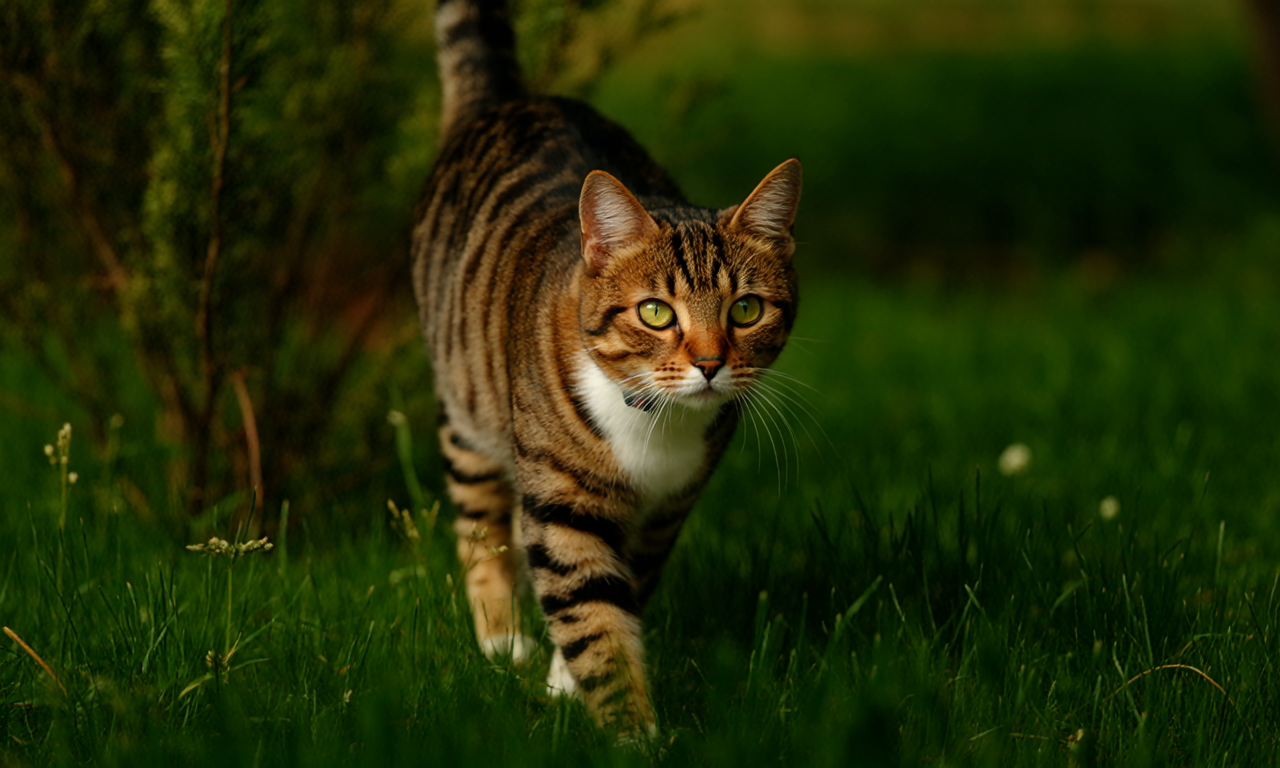

Frame 40 of 81


In [28]:
# Display a sample frame
from IPython.display import Image as IPImage, display
from PIL import Image
import io

frame = frames[len(frames) // 2]  # middle frame
img = Image.fromarray((frame * 255).astype(np.uint8))
buf = io.BytesIO()
img.save(buf, format='PNG')
display(IPImage(data=buf.getvalue()))
print(f"Frame {len(frames)//2} of {len(frames)}")